# Notebook 03: Measuring Performances

This notebook computes **31 verification metrics** for bias-corrected precipitation products. It compares each correction method (**LS, LSEQM, LSEQM+DL**) against three reference datasets (**CPC, IMERGL, IMERGF**) for a user-selected **month and dekad**.

Metrics are organized into four categories:

| Category | Metrics |
|----------|--------|
| **Basic Statistical Metrics** | RB, Pearson CORR, RMSE, MAE, NSE, STDEV, KS |
| **Categorical Event Metrics** | POD, FAR, CSI |
| **Temporal Event Metrics** | FPD, MDWP, DSL |
| **Distributional Metrics** | p25, p50, p75, p90, p95, p99 |

## Metric interpretation (quick guide)

| Metric | Perfect Scores | Typical “good” threshold |
|--------|----------------|--------------------------|
| RB     | 0 (no bias) | within ±0.25 |
| CORR   | 1 (perfect correlation) | > 0.7 |
| RMSE, MAE | 0 (no errors) | lower is better |
| NSE    | 1 (perfect match) | > 0.5 |
| POD    | 1 (all events detected) | > 0.6 |
| FAR    | 0 (no false alarms) | < 0.3 |
| CSI    | 1 (perfect detection) | > 0.5 |

## Two output modes

- **Timeseries (per-year)**: one metric grid per year, dims = (`time`, `lat`, `lon`)  
  Useful for diagnosing year-to-year stability and temporal drift.
- **Single dekad (aggregated)**: all years pooled, dims = (`lat`, `lon`)  
  Useful for a spatial summary of overall correction performance.

---

## 1 Connect Google Drive (Colab only)

This section is only required when running in **Google Colab** and your project/data are stored in Google Drive.

- Mounting Drive makes your repository and datasets accessible under `/content/drive`.
- If you run this notebook locally (Jupyter / VS Code), **skip this section**.

**Expected structure (Drive)**
After mounting, your project root should contain:
- `notebooks/`
- `src/`
- `config.yml` (or `config.yaml`)

Proceed to the code cell below to mount Drive.

In [9]:
from google.colab import drive
import os

# Check if the drive is mounted
if os.path.exists('/content/drive'):
    # Try to unmount
    try:
        drive.flush_and_unmount()
        print("Successfully unmounted")
    except:
        print("Unmount failed, the drive might not be mounted or busy")

# Mount the drive
drive.mount('/content/drive')

Successfully unmounted
Mounted at /content/drive


**Troubleshooting:**  
- If Colab becomes disconnected, Reconnect the runtime and rerun the mounting cell.
- If we receive an error such as `Mountpoint must not already contain files`, delete all the sub-folders under "/content/drive" from the Files panel before retrying. We need to delete these one by one starting from the innermost folders, until the last "drive" folder is deleted.

## 2 Install packages (only if needed)

In most cases, **Google Colab already includes the packages required** for this workflow. The most common missing dependency is **`netCDF4`** (NetCDF I/O support).

### Check what is already installed (Colab)
Before installing anything, you can inspect the current environment by running `!pip list`.

- If all required packages are present and only `netCDF4` is missing, install **only `netCDF4`**.
- If other required packages are missing from `!pip list`, install them **together with** `netCDF4` in the code cell below.

### Local Jupyter note
If you are running in a **local environment** (Jupyter / VS Code), assume all dependencies were installed when preparing the environment following the **main repository README**. In that case, you can skip this section.

Proceed to the code cell below only when installation is necessary.

In [10]:
# In Google Colab, almost all packages already available, except netCDF4
!pip install netCDF4

## 3 Calculating the Metrics

This section computes pixel-wise verification metrics by comparing **reference precipitation** (CPC / IMERGL / IMERGF) against **bias-corrected products** (LS / LSEQM / LSEQM+DL) for the selected month and dekad. The goal is to quantify how each correction method changes accuracy, event detection skill, temporal behavior, and distributional consistency.

Two complementary modes are produced:
- **Timeseries metrics (per-year):** preserves a yearly time axis to evaluate consistency through time.
- **Single-dekad metrics (aggregated):** pools all years to generate one spatial summary grid per combination.

All outputs are written as NetCDF files into method-specific metrics folders (as defined by `config.yml`) and are intended to feed directly into the downstream QA/composite assessment notebook.

---

### Step 1: Setup Environment

This section prepares the notebook runtime so the project modules can be imported and the correct run configuration is used.

The setup typically:
- ensures the **project root** is on the Python path (so `import src...` works),
- loads the central configuration file (`config.yml` / `config.yaml`), and
- confirms the expected directories for:
  - bias-corrected outputs (from Notebook 02),
  - metric outputs produced in this notebook.

**Important**
This notebook assumes Notebook 02 has already generated the corrected products in the output locations defined by the configuration.

Proceed to the code cell below to initialize the environment and configuration.

In [11]:
# Setup: Add project root to Python path
import os
import sys
import importlib

# ---------------------------------------------------------------------------
# Windows DLL fix for conda environments
# ---------------------------------------------------------------------------
if sys.platform == 'win32':
    _conda_prefix = os.environ.get('CONDA_PREFIX') or sys.prefix
    _dll_dirs = [
        os.path.join(_conda_prefix, 'Library', 'bin'),
        os.path.join(_conda_prefix, 'Library', 'lib'),
        os.path.join(_conda_prefix, 'Library', 'mingw-w64', 'bin'),
        os.path.join(_conda_prefix, 'bin'),
        _conda_prefix,
    ]
    for _d in _dll_dirs:
        if os.path.isdir(_d):
            try:
                os.add_dll_directory(_d)
            except OSError:
                pass
            if _d not in os.environ.get('PATH', ''):
                os.environ['PATH'] = _d + os.pathsep + os.environ.get('PATH', '')
    del _conda_prefix, _dll_dirs, _d

# ---------------------------------------------------------------------------
# Project root — hardcoded for local Jupyter.
# Change this path to match your local project location.
# ---------------------------------------------------------------------------

# ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
ROOT = '/content/drive/MyDrive/hybrid-bias-correction'
assert os.path.isfile(os.path.join(ROOT, 'src', 'config.py')), f"Not found: {ROOT}"

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

for m in [k for k in sys.modules if k.startswith('src')]:
    del sys.modules[m]

# Initialize configuration from config.yml
import src.config as _cfg
importlib.reload(_cfg)
# ===========================================================================
# AOI config selector
#   'config.yml'      -> full Indonesia (Zenodo input/output bundle)
#   'config_bali.yml' -> Bali example (ships with the repo, ~11 MB)
# Edit this single line to switch the entire pipeline between the two.
# ===========================================================================
CONFIG_FILE = 'config_bali.yml'

_cfg.initialize_config(os.path.join(ROOT, CONFIG_FILE))

from src import config

print(f"Project root: {ROOT}")
print(f"CPC file:     {config.cpc_file}")
print(f"IMERGL file:  {config.imergl_file}")
print(f"IMERGF file:  {config.imergf_file}")
print(f"NetCDF engine: {config.NETCDF_ENGINE}")
print(f"Metrics path: {config.metrics_path_template}")


2026-05-22 02:43:23,027 - INFO - Loaded configuration from /content/drive/MyDrive/hybrid-bias-correction/config_bali.yml
2026-05-22 02:43:23,030 - INFO - Configured main_dir '/content/hybrid-bias-correction' does not exist on this system. Using auto-detected project root: /content/drive/MyDrive/hybrid-bias-correction
2026-05-22 02:43:23,036 - INFO - Configuration initialized successfully.
2026-05-22 02:43:23,037 - INFO -   Main directory: /content/drive/MyDrive/hybrid-bias-correction
2026-05-22 02:43:23,038 - INFO -   Input directory: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali
2026-05-22 02:43:23,039 - INFO -   Output directory: /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output
2026-05-22 02:43:23,041 - INFO -   Interactive mode: False
Project root: /content/drive/MyDrive/hybrid-bias-correction
CPC file:     /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/bali_cpcuni.nc4
IMERGL file:  /content/drive/MyDrive/hybrid-bias-correctio

### Step 2: User Inputs

Select the month (1--12) and dekad (1, 2, or 3) for which to compute metrics.

In [12]:
# ==============================================================
# Step 2: Gather User Inputs
# ==============================================================

month_input = input('Enter the month (1-12): ').strip()
dekad_input = input('Enter the dekad (1, 2, or 3): ').strip()

try:
    month = int(month_input)
    assert 1 <= month <= 12
except (ValueError, AssertionError):
    raise SystemExit('Invalid month. Please provide a number from 1 to 12.')

try:
    dekad = int(dekad_input)
    assert dekad in (1, 2, 3)
except (ValueError, AssertionError):
    raise SystemExit('Invalid dekad. Must be 1, 2, or 3.')

print(f'\nSelected: month={month}, dekad={dekad}')

Enter the month (1-12): 1
Enter the dekad (1, 2, or 3): 1

Selected: month=1, dekad=1


### Step 3: Timeseries Metrics (per-year)

For each year present in both reference and test data, compute all 31 metrics across the ~10-day dekad window. This produces one metric grid per year, allowing you to track correction quality over time.

Nine combinations are computed: {CPC, IMERGL, IMERGF} x {LS, LSEQM, LSEQM+DL}.

In [13]:
# ==============================================================
# Step 3: Compute Timeseries Metrics
# ==============================================================

from src.metrics import run_metrics_pipeline

ts_files = run_metrics_pipeline(month, dekad, mode='timeseries')

print(f'\nTimeseries output files:')
for f in ts_files:
    if f is not None:
        print(f'  {os.path.basename(f)}')

2026-05-22 02:43:31,260 - INFO - Loading CPC, IMERGL, IMERGF datasets...
2026-05-22 02:43:31,376 - INFO -   cpc: 2001-01-01T00:00:00.000000000 to 2025-12-31T00:00:00.000000000
2026-05-22 02:43:31,378 - INFO -   imergl: 2001-01-01T00:00:00.000000000 to 2025-12-31T00:00:00.000000000
2026-05-22 02:43:31,379 - INFO -   imergf: 2001-01-01T00:00:00.000000000 to 2025-09-30T00:00:00.000000000
2026-05-22 02:43:31,381 - INFO - [1/9] cpc vs imergl_ls
2026-05-22 02:43:31,477 - INFO - CPC regridded: {'time': 9131, 'lat': 9, 'lon': 14} -> {'time': 250, 'lat': 9, 'lon': 14}, 250 common time steps
2026-05-22 02:43:31,506 - INFO - Loading land-sea mask from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/bali_mask.nc (will be cached)
2026-05-22 02:43:31,549 - INFO -   Computing metrics for 25 years...
2026-05-22 02:43:33,164 - INFO -     Year 2005 done (5/25)
2026-05-22 02:43:34,488 - INFO -     Year 2010 done (10/25)
2026-05-22 02:43:35,791 - INFO -     Year 2015 done (15/25)
2026-05-2

### Step 4: Single Dekad Metrics (aggregated)

Pool all years together and compute one summary metric grid per combination. This collapses the temporal dimension, giving a spatial overview of correction quality across the entire record.

In [14]:
# ==============================================================
# Step 4: Compute Single Dekad Metrics
# ==============================================================

from src.metrics import run_metrics_pipeline

sd_files = run_metrics_pipeline(month, dekad, mode='single')

print(f'\nSingle dekad output files:')
for f in sd_files:
    if f is not None:
        print(f'  {os.path.basename(f)}')

2026-05-22 02:44:40,064 - INFO - Loading CPC, IMERGL, IMERGF datasets...
2026-05-22 02:44:40,140 - INFO -   cpc: 2001-01-01T00:00:00.000000000 to 2025-12-31T00:00:00.000000000
2026-05-22 02:44:40,141 - INFO -   imergl: 2001-01-01T00:00:00.000000000 to 2025-12-31T00:00:00.000000000
2026-05-22 02:44:40,142 - INFO -   imergf: 2001-01-01T00:00:00.000000000 to 2025-09-30T00:00:00.000000000
2026-05-22 02:44:40,144 - INFO - [1/9] cpc vs imergl_ls
2026-05-22 02:44:40,221 - INFO - CPC regridded: {'time': 9131, 'lat': 9, 'lon': 14} -> {'time': 250, 'lat': 9, 'lon': 14}, 250 common time steps
2026-05-22 02:44:40,249 - INFO -   Computing aggregated metrics across 250 time steps...
2026-05-22 02:44:40,746 - INFO -   Aggregated metrics complete.
2026-05-22 02:44:40,748 - INFO - File /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/metrics_ls/bali_cli_metricssd_cpc_imergl_ls_month01_dekad01.nc4 already exists.
2026-05-22 02:44:40,749 - INFO - Skipping file /content/drive/MyDrive

### Step 5: Inspect Results

Load one of the output files and visualize a sample metric to verify correctness.

File: bali_cli_metricssd_cpc_imergl_lseqmdl_month01_dekad01.nc4
Variables (31): ['relative_bias', 'pearson_correlation', 'rmse', 'mae', 'ref_stdev', 'test_stdev', 'stdev_ratio', 'pod', 'far', 'csi', 'fpd_ref', 'fpd_test', 'mdwp_ref', 'mdwp_test', 'nse', 'dsl_ref', 'dsl_test', 'ks_stat', 'ks_pvalue', 'p25_ref', 'p25_test', 'p50_ref', 'p50_test', 'p75_ref', 'p75_test', 'p90_ref', 'p90_test', 'p95_ref', 'p95_test', 'p99_ref', 'p99_test']
Dimensions: {'lat': 9, 'lon': 14}


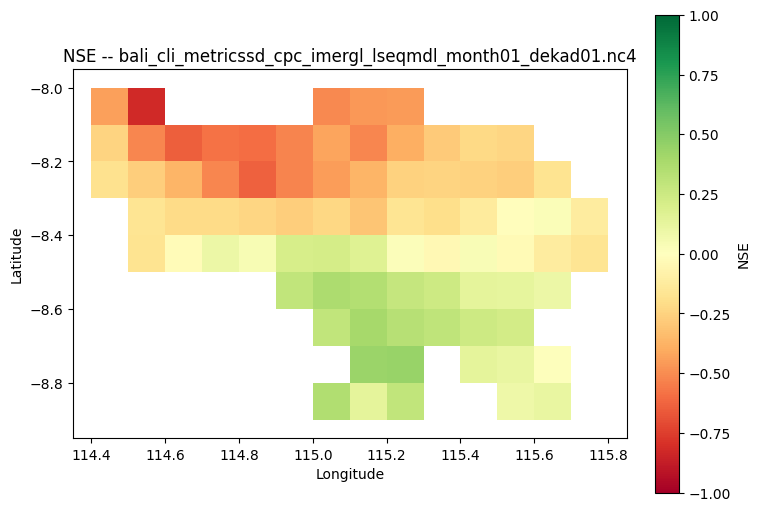

NSE: mean=-0.1077, median=-0.1668, % > 0.5: 0.0%


In [17]:
# ==============================================================
# Step 5: Inspect a Sample Result
# ==============================================================

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Pick the first available single-dekad file (prefer CPC vs LSEQMDL)
sample_file = None
for f in sd_files:
    if f is not None and os.path.isfile(f):
        sample_file = f
        if 'lseqmdl' in f:
            break

if sample_file is not None:
    ds = xr.open_dataset(sample_file, engine=config.NETCDF_ENGINE, decode_timedelta=True)
    print(f'File: {os.path.basename(sample_file)}')
    print(f'Variables ({len(ds.data_vars)}): {list(ds.data_vars)}')
    print(f'Dimensions: {dict(ds.sizes)}')

    # Plot NSE spatial map
    if 'nse' in ds.data_vars:
        nse = ds['nse']
        if 'time' in nse.dims:
            nse = nse.isel(time=-1)

        # Dynamic extent from config AOI (with pad), fallback to data coords
        pad = float(getattr(config, 'MAP_EXTENT_PAD', 0.1))
        aoi_lon = getattr(config, 'AOI_LON_RANGE', None)
        aoi_lat = getattr(config, 'AOI_LAT_RANGE', None)
        xlim = (aoi_lon[0] - pad, aoi_lon[1] + pad) if aoi_lon else (float(nse.lon.min()), float(nse.lon.max()))
        ylim = (aoi_lat[0] - pad, aoi_lat[1] + pad) if aoi_lat else (float(nse.lat.min()), float(nse.lat.max()))
        aspect = (xlim[1] - xlim[0]) / max(ylim[1] - ylim[0], 1e-6)

        fig, ax = plt.subplots(figsize=(min(12, 5 * aspect), 5), constrained_layout=True)
        im = ax.pcolormesh(
            nse.lon, nse.lat, nse.values,
            cmap='RdYlGn', vmin=-1, vmax=1, shading='auto'
        )
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_title(f'NSE -- {os.path.basename(sample_file)}')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.set_aspect('equal')
        fig.colorbar(im, ax=ax, label='NSE')
        plt.show()

        vals = nse.values[~np.isnan(nse.values)]
        if len(vals) > 0:
            print(f'NSE: mean={np.mean(vals):.4f}, '
                  f'median={np.median(vals):.4f}, '
                  f'% > 0.5: {100 * np.mean(vals > 0.5):.1f}%')

    ds.close()
else:
    print('No output files found. Check that corrected precipitation files exist.')


### Step 6: Metric Interpretation Guide

Quick reference for interpreting the 31 metrics.

In [16]:
# ==============================================================
# Step 6: Print Metric Interpretation Reference
# ==============================================================

interpretation = [
    ('Lower is better', 'RMSE, MAE, FAR, |RB|, KS stat'),
    ('Higher is better', 'CORR, NSE, POD, CSI, KS p-value'),
    ('Target similarity', 'Percentiles, STDEV, MDWP, FPD, DSL'),
]

print('Metric Interpretation Guide')
print('=' * 55)
for direction, metrics in interpretation:
    print(f'  {direction:20s}  {metrics}')

print()
print('Units')
print('-' * 55)
print('  mm/day:      RMSE, MAE, STDEV, MDWP, Percentiles')
print('  unitless:    RB, CORR, NSE, POD, FAR, CSI, KS')
print('  percent:     FPD')
print('  days:        DSL')

Metric Interpretation Guide
  Lower is better       RMSE, MAE, FAR, |RB|, KS stat
  Higher is better      CORR, NSE, POD, CSI, KS p-value
  Target similarity     Percentiles, STDEV, MDWP, FPD, DSL

Units
-------------------------------------------------------
  mm/day:      RMSE, MAE, STDEV, MDWP, Percentiles
  unitless:    RB, CORR, NSE, POD, FAR, CSI, KS
  percent:     FPD
  days:        DSL


---


## Summary

This notebook computed 31 verification metrics for 9 reference-vs-test combinations in two modes (timeseries and single dekad). The output NetCDF files are stored in the method-specific metrics directories:

- `data/output/metrics_ls/`
- `data/output/metrics_lseqm/`
- `data/output/metrics_lseqmdl/`

These files feed into notebook `04_qa_framework` for composite quality assessment.

---


## Batch Run - All Months and Dekads

Run this cell to compute **both timeseries and single-dekad metrics** for every
month×dekad combination (12 × 3 = 36 periods, 9 reference×method combos each).

Periods where corrected precipitation files are missing are skipped automatically.

**Prerequisites - run this cell first (skip Steps 2–6):**

| Cell | Purpose |
|------|---------|
| Step 1 | Environment setup, imports, `config` |

In [ ]:
"""
Batch run - metrics for all 36 month×dekad periods.

Requires: config (from Step 1).
"""
from src.metrics import run_metrics_pipeline

n_done = 0
n_skip = 0

for _m in range(1, 13):
    for _d in [1, 2, 3]:
        tag = f"month {_m:02d} dekad {_d}"
        print(f"▸ {tag}  ", end="")
        try:
            run_metrics_pipeline(_m, _d, mode='timeseries')
            run_metrics_pipeline(_m, _d, mode='single')
            n_done += 1
            print("✓")
        except Exception as e:
            n_skip += 1
            print(f"✗ {e}")

print(f"\nBatch complete: {n_done} periods done, {n_skip} skipped.")

▸ month 01 dekad 1  2026-05-20 07:19:16,694 - INFO - Loading CPC, IMERGL, IMERGF datasets...
2026-05-20 07:19:16,995 - INFO -   cpc: 2001-01-01T00:00:00.000000000 to 2025-12-31T00:00:00.000000000
2026-05-20 07:19:16,996 - INFO -   imergl: 2001-01-01T00:00:00.000000000 to 2025-12-31T00:00:00.000000000
2026-05-20 07:19:16,998 - INFO -   imergf: 2001-01-01T00:00:00.000000000 to 2025-09-30T00:00:00.000000000
2026-05-20 07:19:17,380 - INFO - [1/9] cpc vs imergl_ls
2026-05-20 07:19:18,273 - INFO - CPC regridded: {'time': 9131, 'lat': 9, 'lon': 14} -> {'time': 250, 'lat': 9, 'lon': 14}, 250 common time steps
2026-05-20 07:19:18,293 - INFO - Loading land-sea mask from /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/bali_mask.nc (will be cached)
2026-05-20 07:19:18,322 - INFO -   Computing metrics for 25 years...
2026-05-20 07:19:19,653 - INFO -     Year 2005 done (5/25)
2026-05-20 07:19:20,943 - INFO -     Year 2010 done (10/25)
2026-05-20 07:19:22,224 - INFO -     Year 2015 do

/usr/local/lib/python3.12/dist-packages/xarray/core/duck_array_ops.py:258: RuntimeWarning: overflow encountered in cast
  return data.astype(dtype, **kwargs)


2026-05-20 07:36:17,189 - INFO - Saved metrics to /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/metrics_ls/bali_cli_metricsts_cpc_imergl_ls_month05_dekad11.nc4
2026-05-20 07:36:17,193 - INFO -   Done: bali_cli_metricsts_cpc_imergl_ls_month05_dekad11.nc4
2026-05-20 07:36:17,196 - INFO - [2/9] cpc vs imergl_lseqm
2026-05-20 07:36:18,124 - INFO - CPC regridded: {'time': 9131, 'lat': 9, 'lon': 14} -> {'time': 250, 'lat': 9, 'lon': 14}, 250 common time steps
2026-05-20 07:36:18,155 - INFO -   Computing metrics for 25 years...
2026-05-20 07:36:19,275 - INFO -     Year 2005 done (5/25)
2026-05-20 07:36:20,520 - INFO -     Year 2010 done (10/25)
2026-05-20 07:36:22,063 - INFO -     Year 2015 done (15/25)
2026-05-20 07:36:23,858 - INFO -     Year 2020 done (20/25)
2026-05-20 07:36:25,731 - INFO -     Year 2025 done (25/25)
2026-05-20 07:36:26,027 - INFO - Saved metrics to /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/metrics_lseqm/bali_cli_metri

/usr/local/lib/python3.12/dist-packages/xarray/core/duck_array_ops.py:258: RuntimeWarning: overflow encountered in cast
  return data.astype(dtype, **kwargs)


2026-05-20 07:40:01,556 - INFO - CPC regridded: {'time': 9131, 'lat': 9, 'lon': 14} -> {'time': 250, 'lat': 9, 'lon': 14}, 250 common time steps
2026-05-20 07:40:01,612 - INFO -   Computing metrics for 25 years...
2026-05-20 07:40:03,577 - INFO -     Year 2005 done (5/25)
2026-05-20 07:40:05,102 - INFO -     Year 2010 done (10/25)
2026-05-20 07:40:06,291 - INFO -     Year 2015 done (15/25)
2026-05-20 07:40:07,602 - INFO -     Year 2020 done (20/25)
2026-05-20 07:40:08,800 - INFO -     Year 2025 done (25/25)
2026-05-20 07:40:09,075 - INFO - Saved metrics to /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/metrics_lseqm/bali_cli_metricsts_cpc_imergl_lseqm_month06_dekad11.nc4
2026-05-20 07:40:09,080 - INFO -   Done: bali_cli_metricsts_cpc_imergl_lseqm_month06_dekad11.nc4
2026-05-20 07:40:09,086 - INFO - [3/9] cpc vs imergl_lseqmdl
2026-05-20 07:40:09,788 - INFO - CPC regridded: {'time': 9131, 'lat': 9, 'lon': 14} -> {'time': 250, 'lat': 9, 'lon': 14}, 250 common time

...

2026-05-20 07:58:22,049 - INFO - Saved metrics to /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/metrics_ls/bali_cli_metricsts_cpc_imergl_ls_month11_dekad11.nc4
2026-05-20 07:58:22,052 - INFO -   Done: bali_cli_metricsts_cpc_imergl_ls_month11_dekad11.nc4
2026-05-20 07:58:22,054 - INFO - [2/9] cpc vs imergl_lseqm
2026-05-20 07:58:22,762 - INFO - CPC regridded: {'time': 9131, 'lat': 9, 'lon': 14} -> {'time': 250, 'lat': 9, 'lon': 14}, 250 common time steps
2026-05-20 07:58:22,818 - INFO -   Computing metrics for 25 years...
2026-05-20 07:58:24,876 - INFO -     Year 2005 done (5/25)
2026-05-20 07:58:26,537 - INFO -     Year 2010 done (10/25)
2026-05-20 07:58:27,853 - INFO -     Year 2015 done (15/25)
2026-05-20 07:58:29,135 - INFO -     Year 2020 done (20/25)
2026-05-20 07:58:30,423 - INFO -     Year 2025 done (25/25)


/usr/local/lib/python3.12/dist-packages/xarray/core/duck_array_ops.py:258: RuntimeWarning: overflow encountered in cast
  return data.astype(dtype, **kwargs)


2026-05-20 07:58:30,716 - INFO - Saved metrics to /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/metrics_lseqm/bali_cli_metricsts_cpc_imergl_lseqm_month11_dekad11.nc4
2026-05-20 07:58:30,720 - INFO -   Done: bali_cli_metricsts_cpc_imergl_lseqm_month11_dekad11.nc4
2026-05-20 07:58:30,724 - INFO - [3/9] cpc vs imergl_lseqmdl
2026-05-20 07:58:31,558 - INFO - CPC regridded: {'time': 9131, 'lat': 9, 'lon': 14} -> {'time': 250, 'lat': 9, 'lon': 14}, 250 common time steps
2026-05-20 07:58:31,597 - INFO -   Computing metrics for 25 years...
2026-05-20 07:58:32,896 - INFO -     Year 2005 done (5/25)
2026-05-20 07:58:34,165 - INFO -     Year 2010 done (10/25)
2026-05-20 07:58:35,474 - INFO -     Year 2015 done (15/25)
2026-05-20 07:58:37,188 - INFO -     Year 2020 done (20/25)
2026-05-20 07:58:39,205 - INFO -     Year 2025 done (25/25)
2026-05-20 07:58:39,503 - INFO - Saved metrics to /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/metrics_lseqmdl/b

/usr/local/lib/python3.12/dist-packages/xarray/core/duck_array_ops.py:258: RuntimeWarning: overflow encountered in cast
  return data.astype(dtype, **kwargs)


2026-05-20 07:58:39,657 - INFO -   Computing metrics for 25 years...
2026-05-20 07:58:41,299 - INFO -     Year 2005 done (5/25)
2026-05-20 07:58:42,534 - INFO -     Year 2010 done (10/25)
2026-05-20 07:58:43,849 - INFO -     Year 2015 done (15/25)
2026-05-20 07:58:45,143 - INFO -     Year 2020 done (20/25)
2026-05-20 07:58:46,473 - INFO -     Year 2025 done (25/25)
2026-05-20 07:58:46,763 - INFO - Saved metrics to /content/drive/MyDrive/hybrid-bias-correction/data/example_bali/output/metrics_ls/bali_cli_metricsts_imergl_imergl_ls_month11_dekad11.nc4
2026-05-20 07:58:46,765 - INFO -   Done: bali_cli_metricsts_imergl_imergl_ls_month11_dekad11.nc4
2026-05-20 07:58:46,768 - INFO - [5/9] imergl vs imergl_lseqm
2026-05-20 07:58:46,843 - INFO -   Computing metrics for 25 years...
2026-05-20 07:58:48,118 - INFO -     Year 2005 done (5/25)
2026-05-20 07:58:49,343 - INFO -     Year 2010 done (10/25)
2026-05-20 07:58:50,724 - INFO -     Year 2015 done (15/25)
2026-05-20 07:58:52,594 - INFO -     

---

## End of Code